# DeconfoundingFM: observational → counterfactual distributions

This notebook is the main runnable demonstration of **DeconfoundingFM**. We use a deliberately structured two-dimensional outcome so that the modeling advantage is visible rather than hidden by an easy Gaussian target.

We generate

$$
X\sim \mathrm{Unif}[-1,1], \qquad
A\mid X=x\sim \mathrm{Bernoulli}(\sigma(3.2x)),
$$

and

$$
Y = \mu_Z + s(X) + \tau A + \varepsilon,
$$

where $\mu_Z$ is a **three-component Gaussian-mixture structure** with well-separated modes. The effect of $X$ on $Y$ is intentionally moderate relative to this large-scale structure. Thus $P(Y\mid A=1)$ and $P(Y(1))$ already share essentially the same multimodal geometry and differ mainly through the covariate-mixing distribution.

That is exactly the regime DeconfoundingFM is designed for: start from the observed arm distribution and learn the deconfounding edit, rather than reconstructing the whole multimodal distribution from Gaussian noise.

For comparison, we also train the same debiased flow-matching estimator with a standard Gaussian base. The two models share the fitted nuisance estimators, so the comparison isolates the **flow base** rather than nuisance estimation.

> The true $P(Y(1))$ is available below only because this is a synthetic demonstration; it is used for visualization and evaluation, not for training.

In [1]:
import math
from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
import torch

from deconfoundingfm import DeconfoundingFM, DeconfoundingFMConfig

SEED = 7
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = "cpu"  # this demo is intentionally CPU-runnable


## 1. Generate structured observational data

In [2]:
# Three well-separated modes carry most of the geometry of Y.
CENTERS = torch.tensor([
    [-3.4, -1.6],
    [ 0.0,  3.0],
    [ 3.4, -1.4],
])
MIXTURE_WEIGHTS = torch.tensor([0.34, 0.32, 0.34])
NOISE_SD = 0.28
X_EFFECT = 0.95
PROPENSITY_SLOPE = 3.2
TREATMENT_SHIFT = torch.tensor([0.7, 0.35])


def sample_structural_noise(n, device="cpu"):
    centers = CENTERS.to(device)
    weights = MIXTURE_WEIGHTS.to(device)
    component = torch.multinomial(weights, n, replacement=True)
    return centers[component] + NOISE_SD * torch.randn(n, 2, device=device)


def sample_outcome(x, a):
    x = x.reshape(-1)
    a = a.reshape(-1)
    structural = sample_structural_noise(len(x), x.device)
    # X changes the outcome, but only moderately relative to the mode separation.
    x_shift = torch.stack([
        X_EFFECT * x,
        0.22 * torch.sin(math.pi * x),
    ], dim=1)
    return structural + x_shift + a[:, None] * TREATMENT_SHIFT.to(x.device)


n = 1_000
X = 2 * torch.rand(n, 1) - 1
propensity = torch.sigmoid(PROPENSITY_SLOPE * X[:, 0])
A = torch.bernoulli(propensity)
Y = sample_outcome(X, A)

# Synthetic reference samples from P(Y(1)); never supplied to either fitted model.
n_reference = 2_500
X_reference = 2 * torch.rand(n_reference, 1) - 1
Y1_reference = sample_outcome(X_reference, torch.ones(n_reference))
Y1_observed = Y[A == 1]

print(f"n = {n:,}")
print(f"arm counts: A=0: {(A == 0).sum().item()}, A=1: {(A == 1).sum().item()}")
print(f"true propensity range in this sample: [{propensity.min():.3f}, {propensity.max():.3f}]")


n = 1,000
arm counts: A=0: 512, A=1: 488
true propensity range in this sample: [0.039, 0.961]


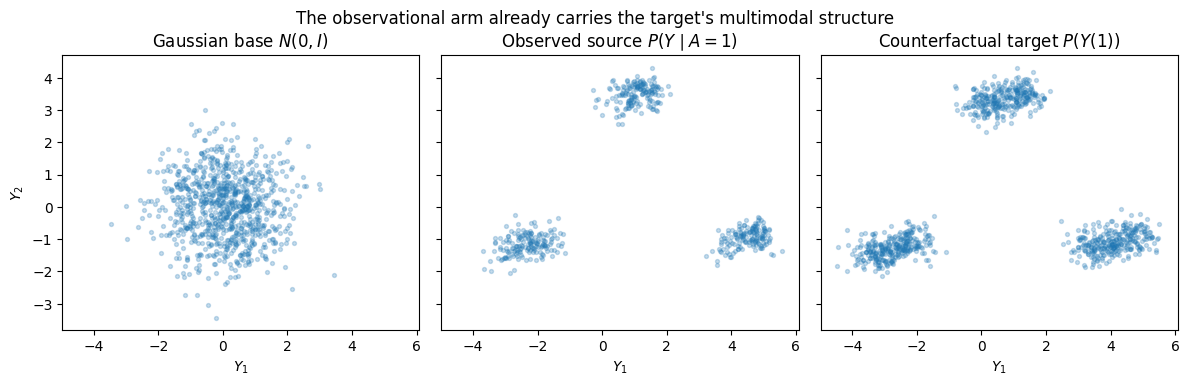

In [3]:
# Before fitting anything, the modeling difference is already visible:
# P(Y|A=1) has the same three-mode structure as P(Y(1)), while N(0,I) does not.
gaussian_base = torch.randn(900, 2)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, sharey=True)
axes[0].scatter(gaussian_base[:, 0], gaussian_base[:, 1], s=8, alpha=0.25)
axes[0].set_title(r"Gaussian base $N(0,I)$")
axes[1].scatter(Y1_observed[:, 0], Y1_observed[:, 1], s=8, alpha=0.25)
axes[1].set_title(r"Observed source $P(Y\mid A=1)$")
axes[2].scatter(Y1_reference[:900, 0], Y1_reference[:900, 1], s=8, alpha=0.25)
axes[2].set_title(r"Counterfactual target $P(Y(1))$")
for ax in axes:
    ax.set_xlabel(r"$Y_1$")
    ax.set_aspect("equal", adjustable="box")
axes[0].set_ylabel(r"$Y_2$")
fig.suptitle("The observational arm already carries the target's multimodal structure")
plt.tight_layout()
plt.show()


## 2. Fit DeconfoundingFM

We use the standard **independent-coupling** estimator here so that the comparison with Gaussian-base flow matching changes only the base distribution. The default random-forest propensity model and conditional flow-matching outcome nuisance are fitted from the observational data.

In [4]:
config = DeconfoundingFMConfig(
    device=DEVICE,
    seed=SEED,
    coupling="independent",
    architecture="mlp",
    base_kind="empirical",
    hidden=64,
    layers=2,
    batch_size=512,
    lr=1e-3,
    epochs=220,
    ode_steps=20,
    nuisance_hidden=64,
    nuisance_layers=2,
    nuisance_batch_size=512,
    nuisance_lr=1e-3,
    nuisance_epochs=120,
    nuisance_ode_steps=14,
    nuisance_base_kind="empirical",
    propensity_trees=100,
    propensity_max_depth=4,
    plugin_reservoir=4,
    plugin_batch=1,
)

decfm = DeconfoundingFM(config).fit(X, A, Y, verbose=False)
print(decfm.diagnostics())


{'n': 1000, 'architecture': 'mlp', 'coupling': 'independent', 'automatic_cross_fitting': False, 'arm_counts': {0: 512, 1: 488}, 'propensity': {'raw_min': 0.009693191386759281, 'raw_max': 0.9486494064331055, 'clipped_min': 0.009999999776482582, 'clipped_max': 0.9486494064331055, 'fraction_clipped': 0.0430000014603138}, 'effective_sample_size': {0: 287.9351806640625, 1: 274.56378173828125}}


## 3. Gaussian-base comparison

The baseline below uses the **same debiased target objective and the same fitted nuisance models**, but replaces the empirical source $P(Y\mid A=a)$ by $N(0,I)$. This makes the comparison intentionally narrow: how much work does the target flow have to do when it starts from the observational geometry versus Gaussian noise?

In [5]:
gaussian_config = replace(config, base_kind="gaussian", seed=SEED + 1)
gaussian_fm = DeconfoundingFM(
    gaussian_config,
    outcome_model=decfm.outcome_model,
    propensity_model=decfm.propensity_model,
).fit(X, A, Y, verbose=False)


In [6]:
@torch.no_grad()
def sliced_w2(x, y, n_projections=128, seed=123):
    """Small deterministic SW2 diagnostic for this 2D demo."""
    x = x.detach().cpu()
    y = y.detach().cpu()
    n = min(len(x), len(y))
    x, y = x[:n], y[:n]
    generator = torch.Generator().manual_seed(seed)
    directions = torch.randn(n_projections, x.shape[1], generator=generator)
    directions = directions / directions.norm(dim=1, keepdim=True)
    xp = x @ directions.T
    yp = y @ directions.T
    xp = xp.sort(dim=0).values
    yp = yp.sort(dim=0).values
    return torch.sqrt(((xp - yp) ** 2).mean()).item()


n_eval = 1_200
with torch.no_grad():
    y_decfm = decfm.sample(a=1, n=n_eval).cpu()
    y_gaussian = gaussian_fm.sample(a=1, n=n_eval).cpu()

# Resample the finite observational arm to use the same Monte Carlo size.
source_idx = torch.randint(len(Y1_observed), (n_eval,))
y_source_eval = Y1_observed[source_idx].cpu()
y_ref_eval = Y1_reference[:n_eval].cpu()

sw2_source = sliced_w2(y_source_eval, y_ref_eval)
sw2_decfm = sliced_w2(y_decfm, y_ref_eval)
sw2_gaussian = sliced_w2(y_gaussian, y_ref_eval)

print(f"SW2 observed source  -> target: {sw2_source:.3f}")
print(f"SW2 DeconfoundingFM  -> target: {sw2_decfm:.3f}")
print(f"SW2 Gaussian-base FM -> target: {sw2_gaussian:.3f}")


SW2 observed source  -> target: 0.388
SW2 DeconfoundingFM  -> target: 0.244
SW2 Gaussian-base FM -> target: 0.477


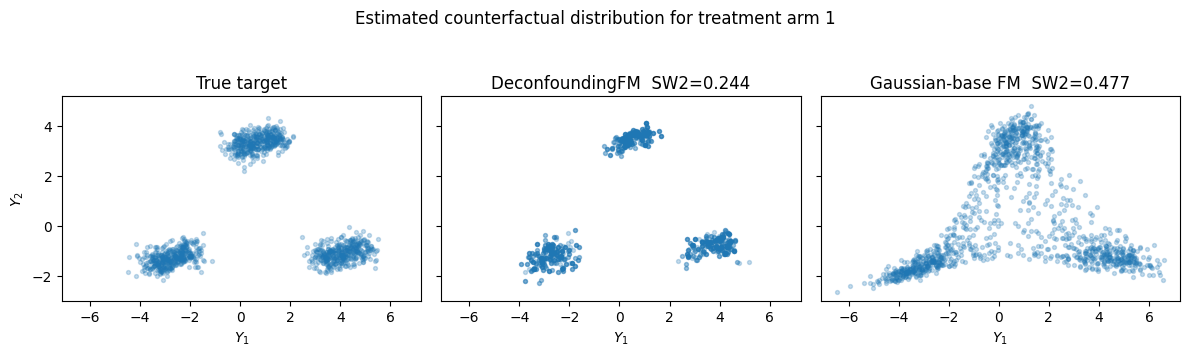

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, sharey=True)
axes[0].scatter(y_ref_eval[:, 0], y_ref_eval[:, 1], s=8, alpha=0.25)
axes[0].set_title("True target")
axes[1].scatter(y_decfm[:, 0], y_decfm[:, 1], s=8, alpha=0.25)
axes[1].set_title(f"DeconfoundingFM  SW2={sw2_decfm:.3f}")
axes[2].scatter(y_gaussian[:, 0], y_gaussian[:, 1], s=8, alpha=0.25)
axes[2].set_title(f"Gaussian-base FM  SW2={sw2_gaussian:.3f}")
for ax in axes:
    ax.set_xlabel(r"$Y_1$")
    ax.set_aspect("equal", adjustable="box")
axes[0].set_ylabel(r"$Y_2$")
fig.suptitle("Estimated counterfactual distribution for treatment arm 1")
plt.tight_layout()
plt.show()


## 4. Visualize the learned transports

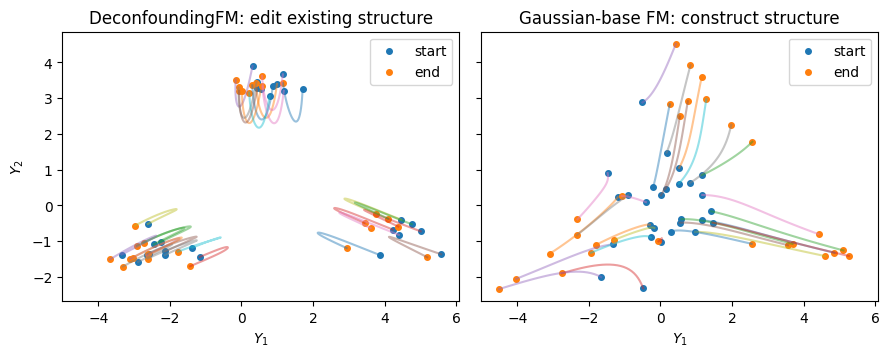

In [8]:
@torch.no_grad()
def trace_flow(model, y0, a=1, steps=24):
    """Trace a small set of points through the learned velocity field."""
    y = y0.clone().to(model.device)
    trajectory = [y.cpu()]
    dt = 1.0 / steps
    context = torch.full((len(y), 1), float(a), device=model.device)
    for k in range(steps):
        t0 = torch.full((len(y),), k * dt, device=model.device)
        tmid = torch.full((len(y),), (k + 0.5) * dt, device=model.device)
        k1 = model.velocity_(y, t0, context)
        ymid = y + 0.5 * dt * k1
        k2 = model.velocity_(ymid, tmid, context)
        y = y + dt * k2
        trajectory.append(y.cpu())
    return torch.stack(trajectory)  # (T+1, N, 2)


n_paths = 28
source_paths = Y1_observed[torch.randperm(len(Y1_observed))[:n_paths]]
gaussian_paths = torch.randn(n_paths, 2)
traj_decfm = trace_flow(decfm, source_paths)
traj_gaussian = trace_flow(gaussian_fm, gaussian_paths)

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
for j in range(n_paths):
    axes[0].plot(traj_decfm[:, j, 0], traj_decfm[:, j, 1], alpha=0.45)
    axes[1].plot(traj_gaussian[:, j, 0], traj_gaussian[:, j, 1], alpha=0.45)
axes[0].scatter(traj_decfm[0, :, 0], traj_decfm[0, :, 1], s=16, label="start")
axes[0].scatter(traj_decfm[-1, :, 0], traj_decfm[-1, :, 1], s=16, label="end")
axes[1].scatter(traj_gaussian[0, :, 0], traj_gaussian[0, :, 1], s=16, label="start")
axes[1].scatter(traj_gaussian[-1, :, 0], traj_gaussian[-1, :, 1], s=16, label="end")
axes[0].set_title("DeconfoundingFM: edit existing structure")
axes[1].set_title("Gaussian-base FM: construct structure")
for ax in axes:
    ax.set_xlabel(r"$Y_1$")
    ax.set_aspect("equal", adjustable="box")
    ax.legend()
axes[0].set_ylabel(r"$Y_2$")
plt.tight_layout()
plt.show()


## Takeaway

The three modes are mostly **outcome structure**, not confounding structure. DeconfoundingFM inherits them for free from $P(Y\mid A=1)$ and learns only the smaller correction induced by the difference between $P(X\mid A=1)$ and $P(X)$. The Gaussian-base model instead has to learn both the multimodal outcome geometry and the counterfactual reweighting.

This is the intended use of the observational distribution as a geometrically adapted flow base. For real data, the same API is simply `fit(X, A, Y)`, followed by `sample(a=...)` or `transform(..., a=...)`.